# Artificial Intelligence and Deep Learning Midterm

## Super-Resolution Generative Adversarial Network

This notebook builds and trains a Super-Resolution GAN that learns to reconstruct 128 × 128 images from 32 × 32 inputs.

The trained generator will later be used to create super-resolved images for Classifier B.

# 1. Imports

In [1]:
import copy
import json
import os
import random
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import VGG19_Weights

print("Imports completed successfully.")

Imports completed successfully.


# 2. Connect Google Drive

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# 3. Project Paths

In [3]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/AI_Midterm"
)

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
MANIFEST_DIR = DATA_DIR / "manifests"
GENERATED_DATA_DIR = DATA_DIR / "generated"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
SRGAN_CHECKPOINT_DIR = CHECKPOINT_DIR / "srgan"

FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

DATASET_ROOT = (
    RAW_DATA_DIR
    / "extracted"
    / "dogs-vs-cats-classification"
)

TRAIN_MANIFEST_PATH = (
    MANIFEST_DIR
    / "train_70_percent.csv"
)

directories = [
    GENERATED_DATA_DIR,
    SRGAN_CHECKPOINT_DIR,
    FIGURES_DIR,
    RESULTS_DIR,
]

for directory in directories:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project paths are ready.")

Project paths are ready.


# 4. Reproducibility and Hardware

In [4]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


# 5. SRGAN Configuration

In [5]:
SRGAN_CONFIG = {
    "high_resolution_size": 128,
    "low_resolution_size": 32,
    "scale_factor": 4,
    "batch_size": 32,
    "num_workers": 2,
    "generator_pretrain_epochs": 10,
    "srgan_epochs": 150,
    "checkpoint_frequency": 5,
    "generator_learning_rate": 1e-4,
    "discriminator_learning_rate": 1e-4,
    "adversarial_weight": 1e-3,
    "content_weight": 1.0,
    "perceptual_weight": 0.006,
    "random_seed": SEED,
}

SRGAN_CONFIG_PATH = (
    RESULTS_DIR
    / "srgan_config.json"
)

with open(
    SRGAN_CONFIG_PATH,
    "w"
) as file:
    json.dump(
        SRGAN_CONFIG,
        file,
        indent=4
    )

print(
    json.dumps(
        SRGAN_CONFIG,
        indent=4
    )
)

{
    "high_resolution_size": 128,
    "low_resolution_size": 32,
    "scale_factor": 4,
    "batch_size": 32,
    "num_workers": 2,
    "generator_pretrain_epochs": 10,
    "srgan_epochs": 150,
    "checkpoint_frequency": 5,
    "generator_learning_rate": 0.0001,
    "discriminator_learning_rate": 0.0001,
    "adversarial_weight": 0.001,
    "content_weight": 1.0,
    "perceptual_weight": 0.006,
    "random_seed": 42
}


# 6. Load the Saved Training Manifest

The SRGAN is trained only on images from the saved 70% training split. The testing images remain excluded from SRGAN training.

In [6]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_ROOT}"
    )

if not TRAIN_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "Training manifest not found at: "
        f"{TRAIN_MANIFEST_PATH}"
    )

train_manifest = pd.read_csv(
    TRAIN_MANIFEST_PATH
)

print(
    f"SRGAN training images: "
    f"{len(train_manifest):,}"
)

print(
    train_manifest["class_name"]
    .value_counts()
)

SRGAN training images: 15,706
class_name
cats    7857
dogs    7849
Name: count, dtype: int64


# 7. Paired Low-Resolution and High-Resolution Dataset

Each image is resized to 128 × 128 to create the high-resolution target. The target is then downscaled to 32 × 32 to create the low-resolution input.

The same random horizontal flip is applied to both versions so the low-resolution and high-resolution images remain aligned.

In [7]:
HR_SIZE = SRGAN_CONFIG[
    "high_resolution_size"
]

LR_SIZE = SRGAN_CONFIG[
    "low_resolution_size"
]


class PairedSuperResolutionDataset(Dataset):

    def __init__(
        self,
        manifest,
        training=True
    ):
        self.manifest = (
            manifest
            .reset_index(drop=True)
            .copy()
        )

        self.training = training

        self.to_tensor = (
            transforms.ToTensor()
        )

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        image_path = Path(
            row["image_path"]
        )

        label = int(
            row["label"]
        )

        image = (
            Image
            .open(image_path)
            .convert("RGB")
        )

        image = image.resize(
            (HR_SIZE, HR_SIZE),
            Image.Resampling.BICUBIC
        )

        if (
            self.training
            and random.random() < 0.5
        ):
            image = image.transpose(
                Image.Transpose.FLIP_LEFT_RIGHT
            )

        hr_image = image

        lr_image = hr_image.resize(
            (LR_SIZE, LR_SIZE),
            Image.Resampling.BICUBIC
        )

        hr_tensor = self.to_tensor(
            hr_image
        )

        lr_tensor = self.to_tensor(
            lr_image
        )

        # Generator output will use Tanh,
        # so HR targets are scaled to [-1, 1].
        hr_tensor = (
            hr_tensor * 2.0 - 1.0
        )

        # LR inputs use the same scale.
        lr_tensor = (
            lr_tensor * 2.0 - 1.0
        )

        return (
            lr_tensor,
            hr_tensor,
            label,
            str(image_path)
        )

# 8. Create the SRGAN Dataset and DataLoader

In [8]:
srgan_train_dataset = (
    PairedSuperResolutionDataset(
        manifest=train_manifest,
        training=True
    )
)

srgan_train_loader = DataLoader(
    srgan_train_dataset,
    batch_size=SRGAN_CONFIG["batch_size"],
    shuffle=True,

    # Use a single process for Google Drive datasets
    num_workers=0,

    pin_memory=torch.cuda.is_available(),

    # Must be False when num_workers=0
    persistent_workers=False
)

print(
    "SRGAN training samples:",
    len(srgan_train_dataset)
)

print(
    "SRGAN training batches:",
    len(srgan_train_loader)
)

SRGAN training samples: 15706
SRGAN training batches: 491


In [9]:
import time

start = time.time()

for batch_number, (
    lr_images,
    hr_images,
    labels,
    paths
) in enumerate(
    srgan_train_loader,
    start=1
):

    print(
        f"Loaded batch {batch_number}",
        lr_images.shape,
        hr_images.shape
    )

    if batch_number == 3:
        break

print(
    f"\nTime for 3 batches: {time.time() - start:.2f} seconds"
)

Loaded batch 1 torch.Size([32, 3, 32, 32]) torch.Size([32, 3, 128, 128])
Loaded batch 2 torch.Size([32, 3, 32, 32]) torch.Size([32, 3, 128, 128])
Loaded batch 3 torch.Size([32, 3, 32, 32]) torch.Size([32, 3, 128, 128])

Time for 3 batches: 111.77 seconds


# 9. Verify a Paired Batch

The low-resolution input should have dimensions 32 × 32, while the corresponding high-resolution target should have dimensions 128 × 128.

In [10]:
lr_batch, hr_batch, label_batch, path_batch = (
    next(
        iter(srgan_train_loader)
    )
)

print(
    "Low-resolution batch shape:",
    lr_batch.shape
)

print(
    "High-resolution batch shape:",
    hr_batch.shape
)

print(
    "Label batch shape:",
    label_batch.shape
)

print(
    "LR value range:",
    lr_batch.min().item(),
    "to",
    lr_batch.max().item()
)

print(
    "HR value range:",
    hr_batch.min().item(),
    "to",
    hr_batch.max().item()
)

Low-resolution batch shape: torch.Size([32, 3, 32, 32])
High-resolution batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])
LR value range: -1.0 to 1.0
HR value range: -1.0 to 1.0


# 10. Visualize Low-Resolution and High-Resolution Pairs

The following figure compares the 32 × 32 low-resolution inputs with their corresponding 128 × 128 high-resolution targets.

In [11]:
def tensor_to_image(image_tensor):
    image = image_tensor.detach().cpu()

    image = (
        image + 1.0
    ) / 2.0

    image = image.clamp(
        0,
        1
    )

    image = image.permute(
        1,
        2,
        0
    ).numpy()

    return image

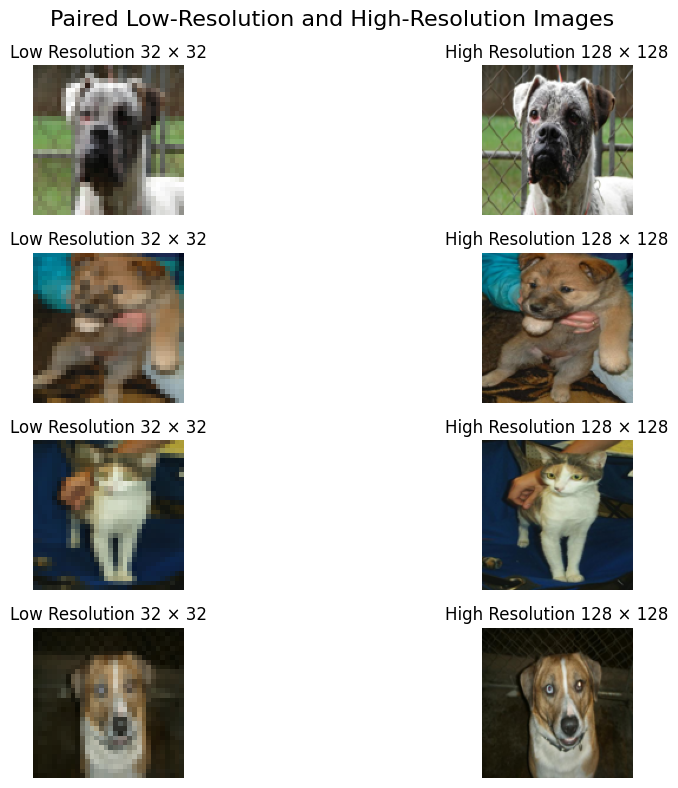

Figure saved to:
/content/drive/MyDrive/AI_Midterm/figures/srgan_lr_hr_pairs.png


In [12]:
num_examples = 4

plt.figure(
    figsize=(12, 8)
)

for index in range(num_examples):

    plt.subplot(
        num_examples,
        2,
        index * 2 + 1
    )

    plt.imshow(
        tensor_to_image(
            lr_batch[index]
        )
    )

    plt.title(
        f"Low Resolution 32 × 32"
    )

    plt.axis("off")

    plt.subplot(
        num_examples,
        2,
        index * 2 + 2
    )

    plt.imshow(
        tensor_to_image(
            hr_batch[index]
        )
    )

    plt.title(
        f"High Resolution 128 × 128"
    )

    plt.axis("off")

plt.suptitle(
    "Paired Low-Resolution and High-Resolution Images",
    fontsize=16
)

plt.tight_layout()

paired_samples_path = (
    FIGURES_DIR
    / "srgan_lr_hr_pairs.png"
)

plt.savefig(
    paired_samples_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to:"
)

print(
    paired_samples_path
)

# 11. Build the SRGAN Generator

The generator receives a 32 × 32 low-resolution image and reconstructs a 128 × 128 image.

The architecture uses:

- an initial convolutional layer;
- residual blocks;
- a long skip connection;
- two upsampling blocks;
- a final Tanh output layer.

In [13]:
class ResidualBlock(nn.Module):

    def __init__(
        self,
        channels=64
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(
                channels
            ),
            nn.PReLU(),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(
                channels
            )
        )

    def forward(
        self,
        x
    ):
        return x + self.block(x)

In [14]:
class UpsampleBlock(nn.Module):

    def __init__(
        self,
        channels=64,
        scale_factor=2
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                channels,
                channels
                * scale_factor
                * scale_factor,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.PixelShuffle(
                scale_factor
            ),
            nn.PReLU()
        )

    def forward(
        self,
        x
    ):
        return self.block(x)

In [15]:
class Generator(nn.Module):

    def __init__(
        self,
        num_residual_blocks=8
    ):
        super().__init__()

        self.initial_block = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=9,
                stride=1,
                padding=4
            ),
            nn.PReLU()
        )

        self.residual_blocks = nn.Sequential(
            *[
                ResidualBlock(
                    channels=64
                )
                for _ in range(
                    num_residual_blocks
                )
            ]
        )

        self.post_residual_block = nn.Sequential(
            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(
                64
            )
        )

        self.upsampling = nn.Sequential(
            UpsampleBlock(
                channels=64,
                scale_factor=2
            ),
            UpsampleBlock(
                channels=64,
                scale_factor=2
            )
        )

        self.output_block = nn.Sequential(
            nn.Conv2d(
                64,
                3,
                kernel_size=9,
                stride=1,
                padding=4
            ),
            nn.Tanh()
        )

    def forward(
        self,
        x
    ):
        initial_features = (
            self.initial_block(x)
        )

        residual_features = (
            self.residual_blocks(
                initial_features
            )
        )

        residual_features = (
            self.post_residual_block(
                residual_features
            )
        )

        combined_features = (
            initial_features
            + residual_features
        )

        upsampled_features = (
            self.upsampling(
                combined_features
            )
        )

        return self.output_block(
            upsampled_features
        )

In [16]:
generator = Generator(
    num_residual_blocks=8
).to(device)

generator.eval()

sample_lr = lr_batch[:4].to(
    device
)

with torch.no_grad():
    sample_sr = generator(
        sample_lr
    )

print(
    "Generator input shape:",
    sample_lr.shape
)

print(
    "Generator output shape:",
    sample_sr.shape
)

print(
    "Generator output range:",
    sample_sr.min().item(),
    "to",
    sample_sr.max().item()
)

Generator input shape: torch.Size([4, 3, 32, 32])
Generator output shape: torch.Size([4, 3, 128, 128])
Generator output range: -0.14043180644512177 to 0.09156369417905807


# 12. Build the SRGAN Discriminator

The discriminator receives a 128 × 128 image and predicts whether it is a real high-resolution image or a super-resolved image produced by the generator.

Strided convolutions reduce the spatial dimensions while the number of feature maps increases.

In [17]:
class DiscriminatorBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride
    ):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=stride,
                padding=1
            ),
            nn.BatchNorm2d(
                out_channels
            ),
            nn.LeakyReLU(
                negative_slope=0.2,
                inplace=True
            )
        ]

        self.block = nn.Sequential(
            *layers
        )

    def forward(
        self,
        x
    ):
        return self.block(x)

In [18]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.initial_block = nn.Sequential(
            nn.Conv2d(
                3,
                64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(
                negative_slope=0.2,
                inplace=True
            )
        )

        self.features = nn.Sequential(
            DiscriminatorBlock(
                64,
                64,
                stride=2
            ),
            DiscriminatorBlock(
                64,
                128,
                stride=1
            ),
            DiscriminatorBlock(
                128,
                128,
                stride=2
            ),
            DiscriminatorBlock(
                128,
                256,
                stride=1
            ),
            DiscriminatorBlock(
                256,
                256,
                stride=2
            ),
            DiscriminatorBlock(
                256,
                512,
                stride=1
            ),
            DiscriminatorBlock(
                512,
                512,
                stride=2
            )
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            ),
            nn.Flatten(),
            nn.Linear(
                512,
                1024
            ),
            nn.LeakyReLU(
                negative_slope=0.2,
                inplace=True
            ),
            nn.Linear(
                1024,
                1
            )
        )

    def forward(
        self,
        x
    ):
        x = self.initial_block(x)
        x = self.features(x)
        return self.classifier(x)

## 12.1 Verify the Discriminator

A batch of real and generated 128 × 128 images is passed through the discriminator. The discriminator should return one logit per image.

In [19]:
discriminator = Discriminator().to(
    device
)

discriminator.eval()

sample_hr = hr_batch[:4].to(
    device
)

with torch.no_grad():
    real_logits = discriminator(
        sample_hr
    )

    fake_logits = discriminator(
        sample_sr
    )

print(
    "Real image input shape:",
    sample_hr.shape
)

print(
    "Real logits shape:",
    real_logits.shape
)

print(
    "Generated image input shape:",
    sample_sr.shape
)

print(
    "Generated logits shape:",
    fake_logits.shape
)

Real image input shape: torch.Size([4, 3, 128, 128])
Real logits shape: torch.Size([4, 1])
Generated image input shape: torch.Size([4, 3, 128, 128])
Generated logits shape: torch.Size([4, 1])


In [20]:
generator_parameters = sum(
    parameter.numel()
    for parameter in generator.parameters()
)

discriminator_parameters = sum(
    parameter.numel()
    for parameter in discriminator.parameters()
)

print(
    f"Generator parameters: "
    f"{generator_parameters:,}"
)

print(
    f"Discriminator parameters: "
    f"{discriminator_parameters:,}"
)

Generator parameters: 956,558
Discriminator parameters: 5,215,425


# 13. Define SRGAN Loss Functions

The generator is trained with three complementary losses:

- **Pixel loss:** encourages the generated image to match the target image at the pixel level.
- **Perceptual loss:** compares high-level features extracted by a pretrained VGG19 network.
- **Adversarial loss:** encourages the generator to produce images that the discriminator classifies as real.

The discriminator uses binary cross-entropy loss to distinguish real high-resolution images from generated images.

In [21]:
class PerceptualLoss(nn.Module):

    def __init__(self):
        super().__init__()

        vgg = models.vgg19(
            weights=VGG19_Weights.DEFAULT
        ).features[:36]

        self.feature_extractor = vgg.eval()

        for parameter in self.feature_extractor.parameters():
            parameter.requires_grad = False

        self.register_buffer(
            "mean",
            torch.tensor(
                [0.485, 0.456, 0.406]
            ).view(1, 3, 1, 1)
        )

        self.register_buffer(
            "std",
            torch.tensor(
                [0.229, 0.224, 0.225]
            ).view(1, 3, 1, 1)
        )

        self.loss_function = nn.MSELoss()

    def normalize_for_vgg(self, images):
        images = (
            images + 1.0
        ) / 2.0

        return (
            images - self.mean
        ) / self.std

    def forward(
        self,
        generated_images,
        target_images
    ):
        generated_normalized = (
            self.normalize_for_vgg(
                generated_images
            )
        )

        target_normalized = (
            self.normalize_for_vgg(
                target_images
            )
        )

        generated_features = (
            self.feature_extractor(
                generated_normalized
            )
        )

        with torch.no_grad():
            target_features = (
                self.feature_extractor(
                    target_normalized
                )
            )

        return self.loss_function(
            generated_features,
            target_features
        )

In [22]:
pixel_criterion = nn.L1Loss()

adversarial_criterion = (
    nn.BCEWithLogitsLoss()
)

perceptual_criterion = (
    PerceptualLoss()
    .to(device)
)

print("Pixel loss:", pixel_criterion)
print(
    "Adversarial loss:",
    adversarial_criterion
)
print(
    "Perceptual loss network ready."
)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 195MB/s]


Pixel loss: L1Loss()
Adversarial loss: BCEWithLogitsLoss()
Perceptual loss network ready.


# 14. Define Optimizers

Separate Adam optimizers are used for the generator and discriminator.

In [23]:
generator_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=SRGAN_CONFIG[
        "generator_learning_rate"
    ],
    betas=(0.9, 0.999)
)

discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=SRGAN_CONFIG[
        "discriminator_learning_rate"
    ],
    betas=(0.9, 0.999)
)

print(
    "Generator optimizer:",
    generator_optimizer.__class__.__name__
)

print(
    "Discriminator optimizer:",
    discriminator_optimizer.__class__.__name__
)

Generator optimizer: Adam
Discriminator optimizer: Adam


## 14.1 Verify the Loss Functions

A small batch is used to confirm that pixel, perceptual, and adversarial losses can all be calculated successfully.

In [24]:
generator.train()
discriminator.train()

sample_lr = lr_batch[:2].to(
    device
)

sample_hr = hr_batch[:2].to(
    device
)

sample_sr = generator(
    sample_lr
)

sample_fake_logits = discriminator(
    sample_sr
)

real_targets = torch.ones_like(
    sample_fake_logits
)

sample_pixel_loss = pixel_criterion(
    sample_sr,
    sample_hr
)

sample_perceptual_loss = (
    perceptual_criterion(
        sample_sr,
        sample_hr
    )
)

sample_adversarial_loss = (
    adversarial_criterion(
        sample_fake_logits,
        real_targets
    )
)

print(
    "Pixel loss:",
    sample_pixel_loss.item()
)

print(
    "Perceptual loss:",
    sample_perceptual_loss.item()
)

print(
    "Adversarial loss:",
    sample_adversarial_loss.item()
)

Pixel loss: 0.4121520519256592
Perceptual loss: 3.1118967533111572
Adversarial loss: 0.6873663663864136


# 15. Pretrain the Generator

Before adversarial training begins, the generator is pretrained using pixel loss only. This encourages it to learn the basic 32 × 32 to 128 × 128 reconstruction task before competing against the discriminator.

In [ ]:
PRETRAIN_EPOCHS = SRGAN_CONFIG[
    "generator_pretrain_epochs"
]

PRETRAIN_CHECKPOINT_PATH = (
    SRGAN_CHECKPOINT_DIR
    / "generator_pretrained.pth"
)

PRETRAIN_LATEST_PATH = (
    SRGAN_CHECKPOINT_DIR
    / "generator_pretrain_latest.pth"
)

pretrain_history = {
    "pixel_loss": []
}

best_pretrain_loss = float("inf")
pretrain_start_epoch = 0

# Resume pretraining if a checkpoint already exists
if PRETRAIN_LATEST_PATH.exists():
    checkpoint = torch.load(
        PRETRAIN_LATEST_PATH,
        map_location=device
    )

    generator.load_state_dict(
        checkpoint["generator_state_dict"]
    )

    generator_optimizer.load_state_dict(
        checkpoint["generator_optimizer_state_dict"]
    )

    pretrain_start_epoch = checkpoint["epoch"]

    pretrain_history = checkpoint.get(
        "history",
        pretrain_history
    )

    best_pretrain_loss = checkpoint.get(
        "best_pretrain_loss",
        best_pretrain_loss
    )

    print(
        f"Resuming generator pretraining at epoch "
        f"{pretrain_start_epoch + 1}."
    )

else:
    print("Starting generator pretraining at epoch 1.")

for epoch in range(
    pretrain_start_epoch,
    PRETRAIN_EPOCHS
):
    epoch_start_time = time.time()

    generator.train()

    running_pixel_loss = 0.0
    total_samples = 0

    for batch_index, (
        lr_images,
        hr_images,
        _,
        _
    ) in enumerate(
        srgan_train_loader,
        start=1
    ):
        lr_images = lr_images.to(
            device,
            non_blocking=True
        )

        hr_images = hr_images.to(
            device,
            non_blocking=True
        )

        generator_optimizer.zero_grad()

        generated_images = generator(
            lr_images
        )

        pixel_loss = pixel_criterion(
            generated_images,
            hr_images
        )

        pixel_loss.backward()
        generator_optimizer.step()

        batch_size = hr_images.size(0)

        running_pixel_loss += (
            pixel_loss.item()
            * batch_size
        )

        total_samples += batch_size

        if (
            batch_index % 50 == 0
            or batch_index == len(
                srgan_train_loader
            )
        ):
            current_average_loss = (
                running_pixel_loss
                / total_samples
            )

            print(
                f"Epoch {epoch + 1:02d}/"
                f"{PRETRAIN_EPOCHS} | "
                f"Batch {batch_index:03d}/"
                f"{len(srgan_train_loader)} | "
                f"Running Pixel Loss: "
                f"{current_average_loss:.4f}"
            )

    epoch_pixel_loss = (
        running_pixel_loss
        / total_samples
    )

    pretrain_history[
        "pixel_loss"
    ].append(
        epoch_pixel_loss
    )

    epoch_minutes = (
        time.time()
        - epoch_start_time
    ) / 60

    print(
        f"Pretrain Epoch "
        f"{epoch + 1:02d}/"
        f"{PRETRAIN_EPOCHS} | "
        f"Pixel Loss: "
        f"{epoch_pixel_loss:.4f} | "
        f"Time: "
        f"{epoch_minutes:.2f} min"
    )

    # Save latest resumable checkpoint after every epoch
    torch.save(
        {
            "epoch": epoch + 1,
            "generator_state_dict":
                generator.state_dict(),
            "generator_optimizer_state_dict":
                generator_optimizer.state_dict(),
            "history":
                pretrain_history,
            "best_pretrain_loss":
                best_pretrain_loss,
            "config":
                SRGAN_CONFIG,
        },
        PRETRAIN_LATEST_PATH
    )

    if epoch_pixel_loss < best_pretrain_loss:
        best_pretrain_loss = (
            epoch_pixel_loss
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "generator_state_dict":
                    generator.state_dict(),
                "generator_optimizer_state_dict":
                    generator_optimizer.state_dict(),
                "pixel_loss":
                    best_pretrain_loss,
                "config":
                    SRGAN_CONFIG,
            },
            PRETRAIN_CHECKPOINT_PATH
        )

        print(
            "Best pretrained generator saved."
        )

Resuming generator pretraining at epoch 11.


## 15.1 Save Generator Pretraining History

In [ ]:
PRETRAIN_HISTORY_PATH = (
    RESULTS_DIR
    / "srgan_pretrain_history.json"
)

with open(
    PRETRAIN_HISTORY_PATH,
    "w"
) as file:
    json.dump(
        pretrain_history,
        file,
        indent=4
    )

print(
    "Pretraining history saved to:"
)

print(
    PRETRAIN_HISTORY_PATH
)

Pretraining history saved to:
/content/drive/MyDrive/AI_Midterm/results/srgan_pretrain_history.json


## 15.2 Visualize Pretraining Loss

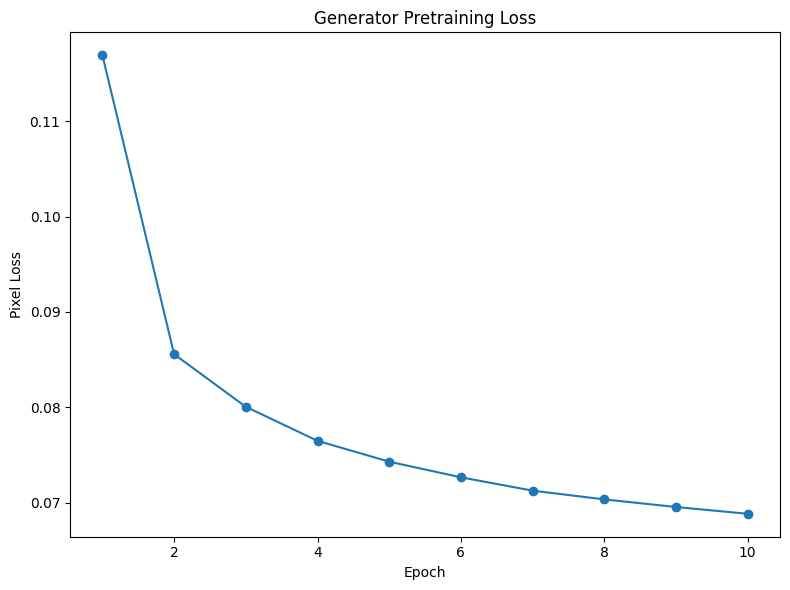

Pretraining loss figure saved to:
/content/drive/MyDrive/AI_Midterm/figures/srgan_generator_pretraining_loss.png


In [ ]:
pretrain_epochs = range(
    1,
    len(pretrain_history["pixel_loss"]) + 1
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    pretrain_epochs,
    pretrain_history["pixel_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Pixel Loss")
plt.title("Generator Pretraining Loss")
plt.tight_layout()

PRETRAIN_LOSS_FIGURE_PATH = (
    FIGURES_DIR
    / "srgan_generator_pretraining_loss.png"
)

plt.savefig(
    PRETRAIN_LOSS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Pretraining loss figure saved to:"
)

print(
    PRETRAIN_LOSS_FIGURE_PATH
)

In [ ]:
pretrain_checkpoint = torch.load(
    PRETRAIN_CHECKPOINT_PATH,
    map_location=device
)

generator.load_state_dict(
    pretrain_checkpoint[
        "generator_state_dict"
    ]
)

print(
    "Loaded pretrained generator "
    f"from epoch "
    f"{pretrain_checkpoint['epoch']}."
)

print(
    "Best pretraining pixel loss:",
    pretrain_checkpoint["pixel_loss"]
)

Loaded pretrained generator from epoch 10.
Best pretraining pixel loss: 0.06883425051321516


# 17. Configure Resumable SRGAN Training

The full SRGAN training process saves the generator, discriminator, optimizer states, epoch number, and training history at regular intervals. This allows training to resume after a Colab disconnection.

In [33]:
SRGAN_EPOCHS = SRGAN_CONFIG["srgan_epochs"]

# Save after every completed epoch
CHECKPOINT_FREQUENCY = 1

LATEST_CHECKPOINT_PATH = (
    SRGAN_CHECKPOINT_DIR
    / "srgan_latest_checkpoint.pth"
)

FINAL_GENERATOR_PATH = (
    SRGAN_CHECKPOINT_DIR
    / "generator_final.pth"
)

FINAL_DISCRIMINATOR_PATH = (
    SRGAN_CHECKPOINT_DIR
    / "discriminator_final.pth"
)

SRGAN_HISTORY_PATH = (
    RESULTS_DIR
    / "srgan_training_history.json"
)

def numbered_checkpoint_path(epoch_number):
    return (
        SRGAN_CHECKPOINT_DIR
        / f"srgan_epoch_{epoch_number:03d}.pth"
    )

srgan_history = {
    "generator_loss": [],
    "discriminator_loss": [],
    "pixel_loss": [],
    "perceptual_loss": [],
    "adversarial_loss": [],
}

start_epoch = 0

# Use None to run until epoch 150.
# Change this to a specific epoch for a controlled stop.
STOP_AFTER_EPOCH = 150

print("Latest checkpoint path:")
print(LATEST_CHECKPOINT_PATH)

print("\nControlled stop:")
print(STOP_AFTER_EPOCH)


Latest checkpoint path:
/content/drive/MyDrive/AI_Midterm/checkpoints/srgan/srgan_latest_checkpoint.pth

Controlled stop:
150


In [ ]:
STOP_AFTER_EPOCH = 10

## 18. Resume Training from the Latest Checkpoint

If a saved checkpoint exists, the model weights, optimizer states, epoch number, and loss history are restored automatically.

In [34]:
if LATEST_CHECKPOINT_PATH.exists():

    checkpoint = torch.load(
        LATEST_CHECKPOINT_PATH,
        map_location=device
    )

    generator.load_state_dict(
        checkpoint["generator_state_dict"]
    )

    discriminator.load_state_dict(
        checkpoint["discriminator_state_dict"]
    )

    generator_optimizer.load_state_dict(
        checkpoint["generator_optimizer_state_dict"]
    )

    discriminator_optimizer.load_state_dict(
        checkpoint["discriminator_optimizer_state_dict"]
    )

    start_epoch = checkpoint["epoch"]

    srgan_history = checkpoint.get(
        "history",
        srgan_history
    )

    print(
        f"Checkpoint loaded. "
        f"Training will resume at epoch {start_epoch + 1}."
    )

else:
    print(
        "No full SRGAN checkpoint found. "
        "Training will begin at epoch 1 using the pretrained generator."
    )

Checkpoint loaded. Training will resume at epoch 131.


In [35]:
print("Start epoch:", start_epoch)
print("Total SRGAN epochs:", SRGAN_EPOCHS)
print("Stop after epoch:", STOP_AFTER_EPOCH)
print("Latest checkpoint path:", LATEST_CHECKPOINT_PATH)

Start epoch: 130
Total SRGAN epochs: 150
Stop after epoch: 150
Latest checkpoint path: /content/drive/MyDrive/AI_Midterm/checkpoints/srgan/srgan_latest_checkpoint.pth


In [ ]:
STOP_AFTER_EPOCH = 20

# 18. Train the Full SRGAN

For each batch:

1. The discriminator learns to distinguish real high-resolution images from generated images.
2. The generator is optimized using pixel, perceptual, and adversarial loss.
3. A complete checkpoint is saved every five epochs.

In [36]:
%who

ADVERSARIAL_WEIGHT	 CHECKPOINT_DIR	 CHECKPOINT_FREQUENCY	 DATASET_ROOT	 DATA_DIR	 DataLoader	 Dataset	 Discriminator	 DiscriminatorBlock	 
FIGURES_DIR	 FINAL_DISCRIMINATOR_PATH	 FINAL_GENERATOR_PATH	 GENERATED_DATA_DIR	 Generator	 HR_SIZE	 Image	 LATEST_CHECKPOINT_PATH	 LR_SIZE	 
MANIFEST_DIR	 PERCEPTUAL_WEIGHT	 PIXEL_WEIGHT	 PROJECT_ROOT	 PairedSuperResolutionDataset	 Path	 PerceptualLoss	 RAW_DATA_DIR	 RESULTS_DIR	 
ResidualBlock	 SEED	 SRGAN_CHECKPOINT_DIR	 SRGAN_CONFIG	 SRGAN_CONFIG_PATH	 SRGAN_EPOCHS	 SRGAN_HISTORY_PATH	 STOP_AFTER_EPOCH	 TRAIN_MANIFEST_PATH	 
UpsampleBlock	 VGG19_Weights	 adversarial_criterion	 adversarial_loss	 bad_files	 batch_number	 batch_size	 checkpoint	 checkpoint_data	 
copy	 device	 directories	 directory	 discriminator	 discriminator_loss	 discriminator_optimizer	 discriminator_parameters	 drive	 
elapsed_minutes	 epoch	 epoch_adversarial_loss	 epoch_discriminator_loss	 epoch_generator_loss	 epoch_minutes	 epoch_perceptual_loss	 epoch_pixel_loss	 epoch_

In [37]:
print("Device:", device)
print("Number of batches:", len(srgan_train_loader))
print("Starting DataLoader test...")

for batch_index, batch in enumerate(srgan_train_loader):
    print("Successfully loaded batch:", batch_index + 1)

    if batch_index >= 4:
        break

print("DataLoader test complete.")

Device: cuda
Number of batches: 491
Starting DataLoader test...
Successfully loaded batch: 1
Successfully loaded batch: 2
Successfully loaded batch: 3
Successfully loaded batch: 4
Successfully loaded batch: 5
DataLoader test complete.


In [38]:
print("Start epoch:", start_epoch)
print("Stop after epoch:", STOP_AFTER_EPOCH)
print("Total epochs:", SRGAN_EPOCHS)

Start epoch: 130
Stop after epoch: 150
Total epochs: 150


In [39]:
PIXEL_WEIGHT = SRGAN_CONFIG["content_weight"]
PERCEPTUAL_WEIGHT = SRGAN_CONFIG["perceptual_weight"]
ADVERSARIAL_WEIGHT = SRGAN_CONFIG["adversarial_weight"]

training_start_time = time.time()

for epoch in range(start_epoch, SRGAN_EPOCHS):

    epoch_start_time = time.time()

    generator.train()
    discriminator.train()

    running_generator_loss = 0.0
    running_discriminator_loss = 0.0
    running_pixel_loss = 0.0
    running_perceptual_loss = 0.0
    running_adversarial_loss = 0.0

    total_samples = 0

    for batch_number, (
        lr_images,
        hr_images,
        _,
        _
    ) in enumerate(
        srgan_train_loader,
        start=1
    ):

        lr_images = lr_images.to(
            device,
            non_blocking=True
        )

        hr_images = hr_images.to(
            device,
            non_blocking=True
        )

        batch_size = hr_images.size(0)

        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )

        # ---------------------------------
        # Train discriminator
        # ---------------------------------
        discriminator_optimizer.zero_grad()

        with torch.no_grad():
            generated_images_for_discriminator = generator(
                lr_images
            )

        real_logits = discriminator(
            hr_images
        )

        fake_logits = discriminator(
            generated_images_for_discriminator.detach()
        )

        real_discriminator_loss = adversarial_criterion(
            real_logits,
            real_targets
        )

        fake_discriminator_loss = adversarial_criterion(
            fake_logits,
            fake_targets
        )

        discriminator_loss = (
            real_discriminator_loss
            + fake_discriminator_loss
        ) / 2.0

        discriminator_loss.backward()
        discriminator_optimizer.step()

        # ---------------------------------
        # Train generator
        # ---------------------------------
        generator_optimizer.zero_grad()

        generated_images = generator(
            lr_images
        )

        generated_logits = discriminator(
            generated_images
        )

        pixel_loss = pixel_criterion(
            generated_images,
            hr_images
        )

        perceptual_loss = perceptual_criterion(
            generated_images,
            hr_images
        )

        adversarial_loss = adversarial_criterion(
            generated_logits,
            real_targets
        )

        generator_loss = (
            PIXEL_WEIGHT * pixel_loss
            + PERCEPTUAL_WEIGHT * perceptual_loss
            + ADVERSARIAL_WEIGHT * adversarial_loss
        )

        generator_loss.backward()
        generator_optimizer.step()

        running_generator_loss += (
            generator_loss.item()
            * batch_size
        )

        running_discriminator_loss += (
            discriminator_loss.item()
            * batch_size
        )

        running_pixel_loss += (
            pixel_loss.item()
            * batch_size
        )

        running_perceptual_loss += (
            perceptual_loss.item()
            * batch_size
        )

        running_adversarial_loss += (
            adversarial_loss.item()
            * batch_size
        )

        total_samples += batch_size

        # ---------------------------------
        # Batch progress counter
        # ---------------------------------
        if (
            batch_number == 1
            or batch_number % 25 == 0
            or batch_number == len(srgan_train_loader)
        ):
            elapsed_minutes = (
                time.time() - epoch_start_time
            ) / 60

            print(
                f"Epoch {epoch + 1:03d}/{SRGAN_EPOCHS} | "
                f"Batch {batch_number:03d}/"
                f"{len(srgan_train_loader)} | "
                f"Elapsed: {elapsed_minutes:.2f} min",
                flush=True
            )

    epoch_generator_loss = (
        running_generator_loss
        / total_samples
    )

    epoch_discriminator_loss = (
        running_discriminator_loss
        / total_samples
    )

    epoch_pixel_loss = (
        running_pixel_loss
        / total_samples
    )

    epoch_perceptual_loss = (
        running_perceptual_loss
        / total_samples
    )

    epoch_adversarial_loss = (
        running_adversarial_loss
        / total_samples
    )

    srgan_history["generator_loss"].append(
        epoch_generator_loss
    )

    srgan_history["discriminator_loss"].append(
        epoch_discriminator_loss
    )

    srgan_history["pixel_loss"].append(
        epoch_pixel_loss
    )

    srgan_history["perceptual_loss"].append(
        epoch_perceptual_loss
    )

    srgan_history["adversarial_loss"].append(
        epoch_adversarial_loss
    )

    epoch_minutes = (
        time.time() - epoch_start_time
    ) / 60

    print(
        f"Epoch {epoch + 1:03d}/{SRGAN_EPOCHS} | "
        f"G Loss: {epoch_generator_loss:.4f} | "
        f"D Loss: {epoch_discriminator_loss:.4f} | "
        f"Pixel: {epoch_pixel_loss:.4f} | "
        f"Perceptual: {epoch_perceptual_loss:.4f} | "
        f"Adversarial: {epoch_adversarial_loss:.4f} | "
        f"Time: {epoch_minutes:.2f} min",
        flush=True
    )

    should_save = (
        (epoch + 1) % CHECKPOINT_FREQUENCY == 0
        or epoch + 1 == SRGAN_EPOCHS
    )

    if should_save:

        checkpoint_data = {
            "epoch": epoch + 1,
            "generator_state_dict":
                generator.state_dict(),
            "discriminator_state_dict":
                discriminator.state_dict(),
            "generator_optimizer_state_dict":
                generator_optimizer.state_dict(),
            "discriminator_optimizer_state_dict":
                discriminator_optimizer.state_dict(),
            "history":
                srgan_history,
            "config":
                SRGAN_CONFIG,
        }

        torch.save(
            checkpoint_data,
            LATEST_CHECKPOINT_PATH
        )

        torch.save(
            checkpoint_data,
            numbered_checkpoint_path(
                epoch + 1
            )
        )

        with open(
            SRGAN_HISTORY_PATH,
            "w"
        ) as file:
            json.dump(
                srgan_history,
                file,
                indent=4
            )

        print(
            f"Checkpoint saved after epoch {epoch + 1}.",
            flush=True
        )

    if (
        STOP_AFTER_EPOCH is not None
        and epoch + 1 >= STOP_AFTER_EPOCH
    ):
        print(
            f"Controlled stop reached after epoch {epoch + 1}.",
            flush=True
        )
        break

Epoch 131/150 | Batch 001/491 | Elapsed: 0.00 min
Epoch 131/150 | Batch 025/491 | Elapsed: 0.12 min
Epoch 131/150 | Batch 050/491 | Elapsed: 0.23 min
Epoch 131/150 | Batch 075/491 | Elapsed: 0.35 min
Epoch 131/150 | Batch 100/491 | Elapsed: 0.46 min
Epoch 131/150 | Batch 125/491 | Elapsed: 0.57 min
Epoch 131/150 | Batch 150/491 | Elapsed: 0.69 min
Epoch 131/150 | Batch 175/491 | Elapsed: 0.80 min
Epoch 131/150 | Batch 200/491 | Elapsed: 0.92 min
Epoch 131/150 | Batch 225/491 | Elapsed: 1.03 min
Epoch 131/150 | Batch 250/491 | Elapsed: 1.15 min
Epoch 131/150 | Batch 275/491 | Elapsed: 1.26 min
Epoch 131/150 | Batch 300/491 | Elapsed: 1.38 min
Epoch 131/150 | Batch 325/491 | Elapsed: 1.49 min
Epoch 131/150 | Batch 350/491 | Elapsed: 1.61 min
Epoch 131/150 | Batch 375/491 | Elapsed: 1.72 min
Epoch 131/150 | Batch 400/491 | Elapsed: 1.84 min
Epoch 131/150 | Batch 425/491 | Elapsed: 1.95 min
Epoch 131/150 | Batch 450/491 | Elapsed: 2.07 min
Epoch 131/150 | Batch 475/491 | Elapsed: 2.18 min


In [40]:
from PIL import Image
from pathlib import Path

bad_files = []

for file in DATASET_ROOT.rglob("*"):
    if file.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]:
        try:
            with Image.open(file) as img:
                img.verify()
        except Exception as e:
            bad_files.append((file, str(e)))

print(f"Found {len(bad_files)} corrupt files.")

for f, err in bad_files:
    print(f)
    print(err)
    print("-" * 60)

Found 0 corrupt files.


In [41]:
checkpoint = torch.load(
    LATEST_CHECKPOINT_PATH,
    map_location="cpu"
)

print("Latest saved epoch:", checkpoint["epoch"])
print("History length:", len(checkpoint["history"]["generator_loss"]))

Latest saved epoch: 150
History length: 152


In [32]:
from PIL import Image
from pathlib import Path

bad_files = []

for img_path in DATASET_ROOT.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            bad_files.append((img_path, str(e)))

print(f"Found {len(bad_files)} corrupted images.")

for f, err in bad_files[:20]:
    print(f)
    print(err)
    print()

Found 0 corrupted images.


# 19. Save the Final Generator and Discriminator

In [42]:
torch.save(
    {
        "model_state_dict":
            generator.state_dict(),
        "config":
            SRGAN_CONFIG,
    },
    FINAL_GENERATOR_PATH
)

torch.save(
    {
        "model_state_dict":
            discriminator.state_dict(),
        "config":
            SRGAN_CONFIG,
    },
    FINAL_DISCRIMINATOR_PATH
)

with open(
    SRGAN_HISTORY_PATH,
    "w"
) as file:
    json.dump(
        srgan_history,
        file,
        indent=4
    )

print("Final generator saved to:")
print(FINAL_GENERATOR_PATH)

print("\nFinal discriminator saved to:")
print(FINAL_DISCRIMINATOR_PATH)

print("\nTraining history saved to:")
print(SRGAN_HISTORY_PATH)

Final generator saved to:
/content/drive/MyDrive/AI_Midterm/checkpoints/srgan/generator_final.pth

Final discriminator saved to:
/content/drive/MyDrive/AI_Midterm/checkpoints/srgan/discriminator_final.pth

Training history saved to:
/content/drive/MyDrive/AI_Midterm/results/srgan_training_history.json


# 20. Visualize SRGAN Training History

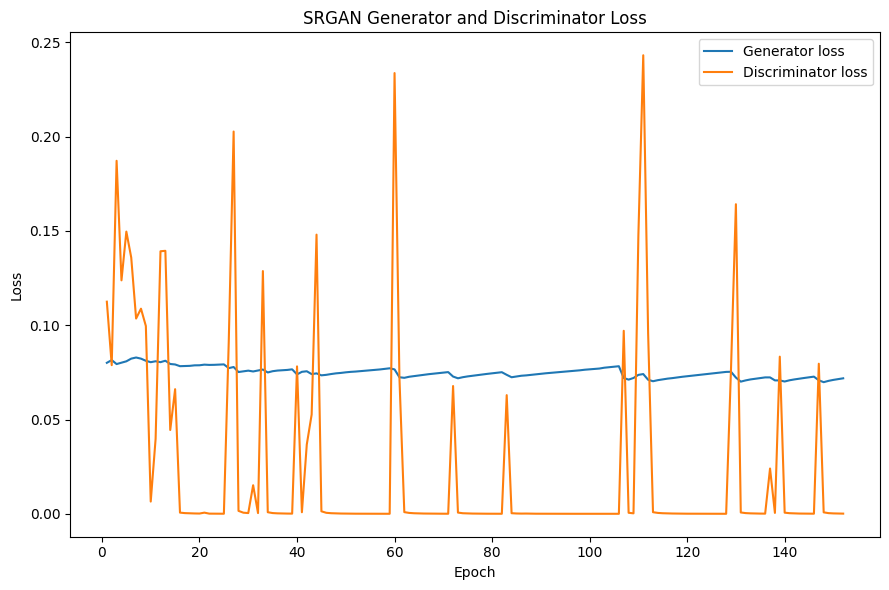

In [43]:
srgan_epochs_completed = range(
    1,
    len(srgan_history["generator_loss"]) + 1
)

plt.figure(figsize=(9, 6))

plt.plot(
    srgan_epochs_completed,
    srgan_history["generator_loss"],
    label="Generator loss"
)

plt.plot(
    srgan_epochs_completed,
    srgan_history["discriminator_loss"],
    label="Discriminator loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SRGAN Generator and Discriminator Loss")
plt.legend()
plt.tight_layout()

gan_loss_path = (
    FIGURES_DIR /
    "srgan_generator_discriminator_loss.png"
)

plt.savefig(
    gan_loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

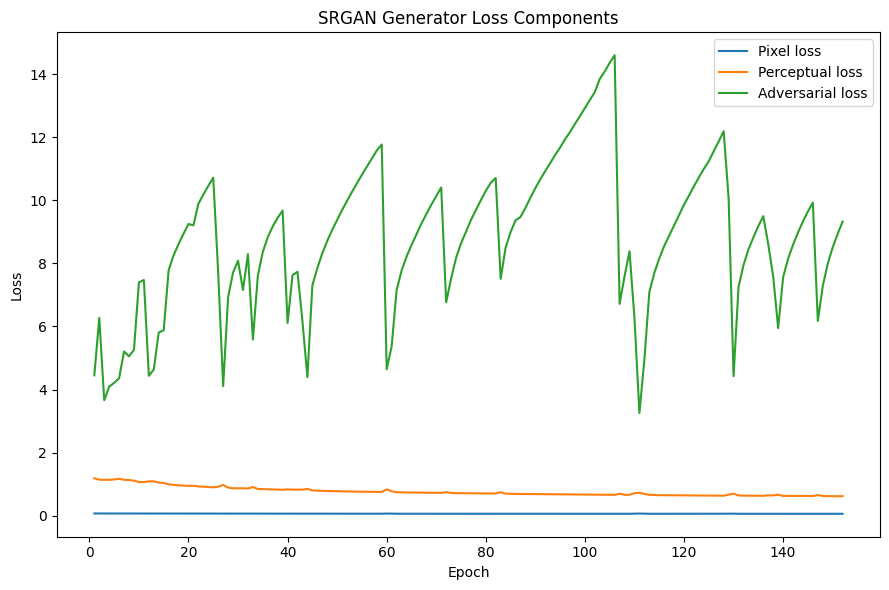

In [44]:
plt.figure(figsize=(9, 6))

plt.plot(
    srgan_epochs_completed,
    srgan_history["pixel_loss"],
    label="Pixel loss"
)

plt.plot(
    srgan_epochs_completed,
    srgan_history["perceptual_loss"],
    label="Perceptual loss"
)

plt.plot(
    srgan_epochs_completed,
    srgan_history["adversarial_loss"],
    label="Adversarial loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SRGAN Generator Loss Components")
plt.legend()
plt.tight_layout()

loss_components_path = (
    FIGURES_DIR /
    "srgan_loss_components.png"
)

plt.savefig(
    loss_components_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
TEST_MANIFEST_PATH = (
    MANIFEST_DIR /
    "test_30_percent.csv"
)

test_manifest = pd.read_csv(
    TEST_MANIFEST_PATH
)

srgan_test_dataset = PairedSuperResolutionDataset(
    manifest=test_manifest,
    training=False
)

srgan_test_loader = DataLoader(
    srgan_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True
)

print(
    "SRGAN evaluation samples:",
    len(srgan_test_dataset)
)

SRGAN evaluation samples: 6732


# 21. Visualize Super-Resolved Images

The generated images are compared with the original low-resolution inputs, bicubic interpolation, and the real high-resolution targets.

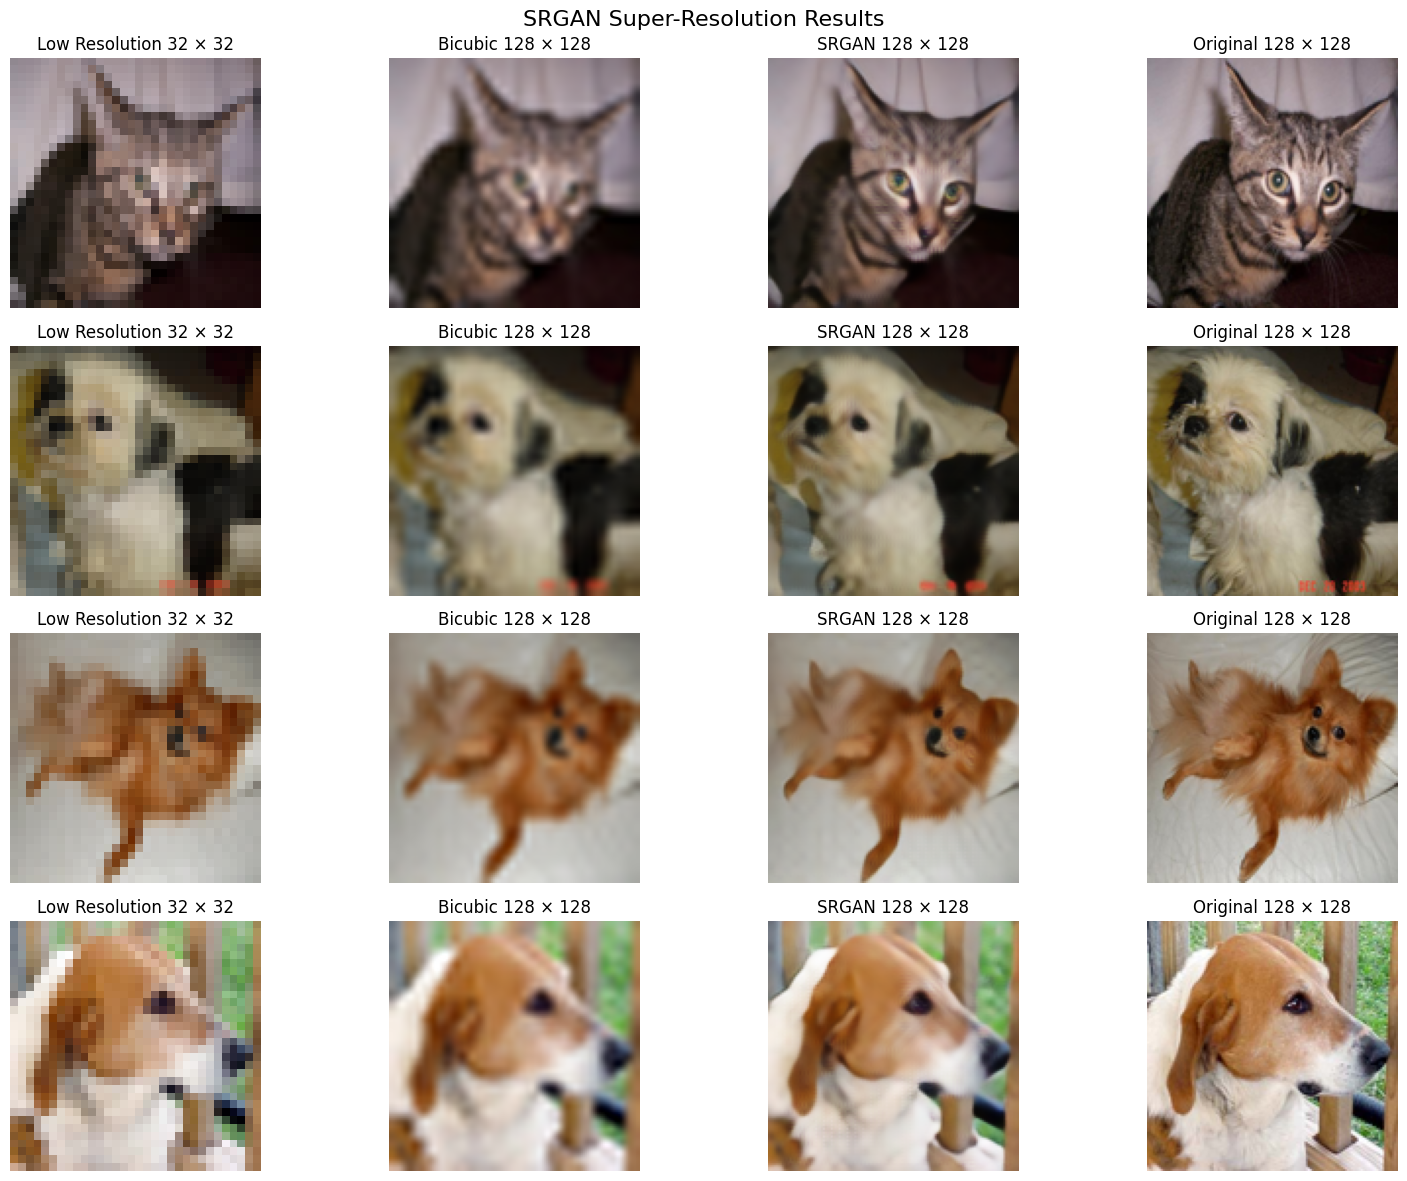

In [46]:
import torch.nn.functional as F

generator.eval()

test_lr, test_hr, test_labels, test_paths = next(
    iter(srgan_test_loader)
)

test_lr_device = test_lr.to(device)

with torch.no_grad():
    test_sr = generator(
        test_lr_device
    ).cpu()

bicubic_images = F.interpolate(
    test_lr,
    size=(128, 128),
    mode="bicubic",
    align_corners=False
)

num_examples = 4

plt.figure(
    figsize=(16, 12)
)

for index in range(num_examples):

    images_to_show = [
        test_lr[index],
        bicubic_images[index],
        test_sr[index],
        test_hr[index],
    ]

    titles = [
        "Low Resolution 32 × 32",
        "Bicubic 128 × 128",
        "SRGAN 128 × 128",
        "Original 128 × 128",
    ]

    for column, (
        image_tensor,
        title
    ) in enumerate(
        zip(images_to_show, titles)
    ):

        plt.subplot(
            num_examples,
            4,
            index * 4 + column + 1
        )

        plt.imshow(
            tensor_to_image(
                image_tensor
            )
        )

        plt.title(title)
        plt.axis("off")

plt.suptitle(
    "SRGAN Super-Resolution Results",
    fontsize=16
)

plt.tight_layout()

comparison_figure_path = (
    FIGURES_DIR /
    "srgan_super_resolution_examples.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.2 MB/s eta 0:00:00


In [48]:
from torchmetrics.image import (
    PeakSignalNoiseRatio,
    StructuralSimilarityIndexMeasure
)

psnr_metric = PeakSignalNoiseRatio(
    data_range=2.0
).to(device)

ssim_metric = StructuralSimilarityIndexMeasure(
    data_range=2.0
).to(device)

generator.eval()

psnr_values = []
ssim_values = []

with torch.no_grad():

    for lr_images, hr_images, _, _ in srgan_test_loader:

        lr_images = lr_images.to(
            device,
            non_blocking=True
        )

        hr_images = hr_images.to(
            device,
            non_blocking=True
        )

        sr_images = generator(
            lr_images
        )

        batch_psnr = psnr_metric(
            sr_images,
            hr_images
        )

        batch_ssim = ssim_metric(
            sr_images,
            hr_images
        )

        psnr_values.append(
            batch_psnr.item()
        )

        ssim_values.append(
            batch_ssim.item()
        )

average_psnr = float(
    np.mean(psnr_values)
)

average_ssim = float(
    np.mean(ssim_values)
)

print(
    f"Average PSNR: "
    f"{average_psnr:.4f} dB"
)

print(
    f"Average SSIM: "
    f"{average_ssim:.4f}"
)

Average PSNR: 26.2467 dB
Average SSIM: 0.7687


In [49]:
srgan_metrics = {
    "average_psnr_db": average_psnr,
    "average_ssim": average_ssim,
    "evaluation_images": len(srgan_test_dataset),
}

SRGAN_METRICS_PATH = (
    RESULTS_DIR /
    "srgan_image_quality_metrics.json"
)

with open(
    SRGAN_METRICS_PATH,
    "w"
) as file:
    json.dump(
        srgan_metrics,
        file,
        indent=4
    )

print(
    "SRGAN quality metrics saved to:"
)

print(
    SRGAN_METRICS_PATH
)

SRGAN quality metrics saved to:
/content/drive/MyDrive/AI_Midterm/results/srgan_image_quality_metrics.json


# 22. Generate the Classifier B Training Dataset

The trained generator is applied to every image in the original 70% training split. The generated 128 × 128 images are saved in class-specific folders for Classifier B.

In [50]:
from torchvision.utils import save_image

CLASSIFIER_B_DATA_DIR = (
    GENERATED_DATA_DIR /
    "classifier_B_train"
)

CAT_OUTPUT_DIR = (
    CLASSIFIER_B_DATA_DIR /
    "cats"
)

DOG_OUTPUT_DIR = (
    CLASSIFIER_B_DATA_DIR /
    "dogs"
)

CAT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DOG_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

generator.eval()

generated_count = 0

with torch.no_grad():

    for lr_images, _, labels, image_paths in srgan_train_loader:

        lr_images = lr_images.to(
            device,
            non_blocking=True
        )

        sr_images = generator(
            lr_images
        )

        sr_images = (
            sr_images + 1.0
        ) / 2.0

        sr_images = sr_images.clamp(
            0,
            1
        )

        for index in range(
            sr_images.size(0)
        ):

            label = int(
                labels[index]
            )

            original_name = Path(
                image_paths[index]
            ).stem

            output_directory = (
                CAT_OUTPUT_DIR
                if label == 0
                else DOG_OUTPUT_DIR
            )

            output_path = (
                output_directory /
                f"{original_name}_sr.png"
            )

            save_image(
                sr_images[index],
                output_path
            )

            generated_count += 1

        if generated_count % 1000 < sr_images.size(0):
            print(
                f"Generated "
                f"{generated_count:,} images."
            )

print(
    f"Finished generating "
    f"{generated_count:,} images."
)

Generated 1,024 images.
Generated 2,016 images.
Generated 3,008 images.
Generated 4,000 images.
Generated 5,024 images.


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Generated 6,016 images.
Generated 7,008 images.
Generated 8,000 images.
Generated 9,024 images.
Generated 10,016 images.
Generated 11,008 images.
Generated 12,000 images.
Generated 13,024 images.
Generated 14,016 images.
Generated 15,008 images.
Finished generating 15,706 images.


In [51]:
generated_cat_count = len(
    list(
        CAT_OUTPUT_DIR.glob("*.png")
    )
)

generated_dog_count = len(
    list(
        DOG_OUTPUT_DIR.glob("*.png")
    )
)

print(
    "Generated cat images:",
    generated_cat_count
)

print(
    "Generated dog images:",
    generated_dog_count
)

print(
    "Total generated images:",
    generated_cat_count
    + generated_dog_count
)

Generated cat images: 7857
Generated dog images: 7849
Total generated images: 15706
